## 1. Import Libraries

In [ ]:
!pip install datasets -q

import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Device Configuration

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 50)
print(f"Using device : {device}")
print("=" * 50)

Using device : cuda


In [ ]:
print("Downloading / loading CIFAR-10 from Hugging Face Hub...")
cifar10 = load_dataset("uoft-cs/cifar10")

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class CIFAR10HFDataset(Dataset):
    """Wraps a Hugging Face CIFAR-10 split for use with a PyTorch DataLoader."""

    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        example = self.hf_split[idx]
        image = example["img"].convert("RGB")
        label = example["label"]
        image = self.transform(image)
        return image, label


train_dataset = CIFAR10HFDataset(cifar10["train"], train_transform)
test_dataset = CIFAR10HFDataset(cifar10["test"], eval_transform)

sample_img, sample_label = train_dataset[0]
raw_img = cifar10["train"][0]["img"]

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Training samples      : {len(train_dataset)}")
print(f"Testing samples       : {len(test_dataset)}")
print(f"Raw image size         : {raw_img.size} (PIL, WxH)")
print(f"Transformed image shape: {tuple(sample_img.shape)}")
print(f"Number of classes      : {len(class_names)}")
print(f"Class names            : {class_names}")
print("=" * 50)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DATASET SUMMARY
Training samples      : 50000
Testing samples       : 10000
Raw image size         : (32, 32) (PIL, WxH)
Transformed image shape: (3, 224, 224)
Number of classes      : 10
Class names            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. Display Ten Sample Images

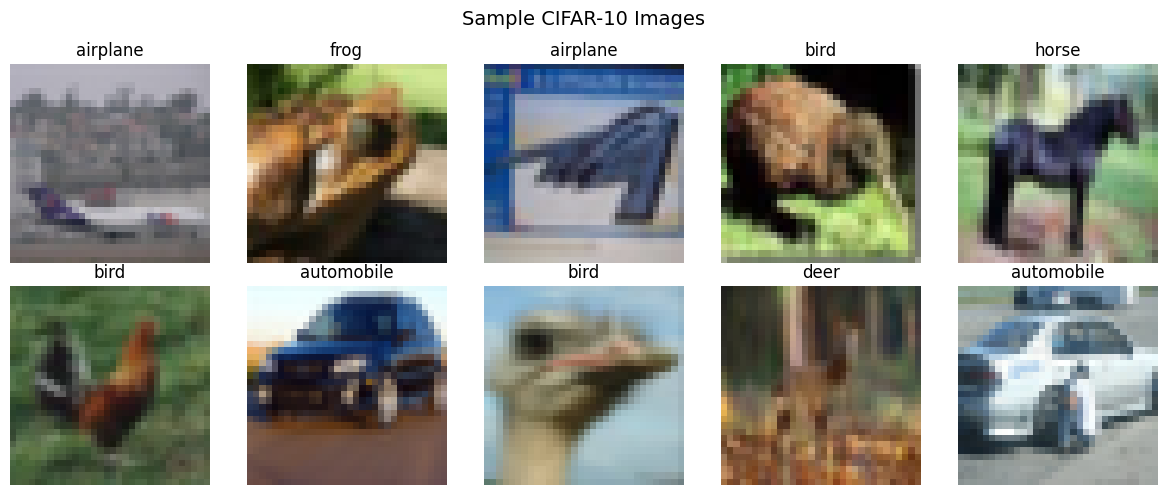

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    example = cifar10["train"][i]
    ax.imshow(example["img"])
    ax.set_title(class_names[example["label"]])
    ax.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()
plt.savefig("plot1.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Dataset Information

In [ ]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(f"Dataset name         : CIFAR-10 (uoft-cs/cifar10, Hugging Face)")
print(f"Original image size  : 32 x 32 x 3")
print(f"Resized image size   : {IMG_SIZE} x {IMG_SIZE} x 3")
print(f"Number of classes    : {len(class_names)}")
print(f"Training images      : {len(train_dataset)}")
print(f"Testing images       : {len(test_dataset)}")
print("=" * 50)

DATASET INFORMATION
Dataset name         : CIFAR-10 (uoft-cs/cifar10, Hugging Face)
Original image size  : 32 x 32 x 3
Resized image size   : 224 x 224 x 3
Number of classes    : 10
Training images      : 50000
Testing images       : 10000


In [ ]:
evolution_table = pd.DataFrame({
    "Model": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet"],
    "Year": [1998, 2012, 2014, 2014, 2015],
    "Major Contribution": [
        "First practical convolutional neural network",
        "ReLU activation, Dropout and GPU training",
        "Uniform 3x3 convolution filters",
        "Inception modules for multi-scale feature extraction",
        "Residual learning using skip connections",
    ],
})

print("=" * 50)
print("EVOLUTION OF CNN ARCHITECTURES")
print("=" * 50)
print(evolution_table.to_string(index=False))

comparison_table = pd.DataFrame({
    "Architecture": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50"],
    "Depth": [7, 8, 16, 22, 50],
    "Parameters": ["60K", "61M", "138M", "6.8M", "25.6M"],
    "Main Contribution": [
        "First CNN",
        "ReLU + Dropout",
        "Deep 3x3 filters",
        "Inception Modules",
        "Residual Learning",
    ],
})

print()
print("=" * 50)
print("COMPARISON OF ARCHITECTURES (LITERATURE REFERENCE)")
print("=" * 50)
print(comparison_table.to_string(index=False))

EVOLUTION OF CNN ARCHITECTURES
    Model  Year                                   Major Contribution
  LeNet-5  1998         First practical convolutional neural network
  AlexNet  2012            ReLU activation, Dropout and GPU training
    VGG16  2014                      Uniform 3x3 convolution filters
GoogleNet  2014 Inception modules for multi-scale feature extraction
   ResNet  2015             Residual learning using skip connections

COMPARISON OF ARCHITECTURES (LITERATURE REFERENCE)
Architecture  Depth Parameters Main Contribution
     LeNet-5      7        60K         First CNN
     AlexNet      8        61M    ReLU + Dropout
       VGG16     16       138M  Deep 3x3 filters
   GoogleNet     22       6.8M Inception Modules
    ResNet50     50      25.6M Residual Learning


In [ ]:
weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)

# Freeze the convolutional base
for param in model.parameters():
    param.requires_grad = False

# Replace the classification head
# model.avgpool is ResNet50's existing Global Average Pooling layer
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, len(class_names)),
)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("MODEL SUMMARY")
print("=" * 50)
print("Backbone              : ResNet50 (ImageNet pretrained)")
print("Convolutional base    : Frozen")
print("Head                  : GAP -> Linear(256) -> ReLU -> Dropout -> Linear(10)")
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Frozen parameters     : {total_params - trainable_params:,}")
print("=" * 50)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


MODEL SUMMARY
Backbone              : ResNet50 (ImageNet pretrained)
Convolutional base    : Frozen
Head                  : GAP -> Linear(256) -> ReLU -> Dropout -> Linear(10)
Total parameters      : 24,035,146
Trainable parameters  : 527,114
Frozen parameters     : 23,508,032


In [ ]:
BATCH_SIZE = 32
EPOCHS_FROZEN = 10
LEARNING_RATE = 0.001

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)


def run_epoch(model, loader, criterion, optimizer=None):
    """Runs one training epoch if optimizer is given, else one evaluation epoch."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    torch.set_grad_enabled(is_train)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


history_frozen = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("=" * 50)
print("TRAINING - FROZEN BACKBONE")
print("=" * 50)

start_time = time.time()

for epoch in range(EPOCHS_FROZEN):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, test_loader, criterion, optimizer=None)

    history_frozen["train_loss"].append(train_loss)
    history_frozen["train_acc"].append(train_acc)
    history_frozen["val_loss"].append(val_loss)
    history_frozen["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS_FROZEN}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

frozen_training_time = time.time() - start_time

print("=" * 50)
print(f"Frozen-backbone training time: {frozen_training_time:.2f} seconds")
print("=" * 50)

TRAINING - FROZEN BACKBONE
Epoch [1/10]  Train Loss: 0.7751  Train Acc: 0.7380  Val Loss: 0.5757  Val Acc: 0.8035
Epoch [2/10]  Train Loss: 0.6143  Train Acc: 0.7891  Val Loss: 0.5488  Val Acc: 0.8135
Epoch [3/10]  Train Loss: 0.5738  Train Acc: 0.8012  Val Loss: 0.5210  Val Acc: 0.8212
Epoch [4/10]  Train Loss: 0.5449  Train Acc: 0.8114  Val Loss: 0.5411  Val Acc: 0.8134
Epoch [5/10]  Train Loss: 0.5201  Train Acc: 0.8187  Val Loss: 0.5100  Val Acc: 0.8209
Epoch [6/10]  Train Loss: 0.4975  Train Acc: 0.8235  Val Loss: 0.5254  Val Acc: 0.8174
Epoch [7/10]  Train Loss: 0.4762  Train Acc: 0.8319  Val Loss: 0.5097  Val Acc: 0.8271
Epoch [8/10]  Train Loss: 0.4640  Train Acc: 0.8359  Val Loss: 0.5161  Val Acc: 0.8244
Epoch [9/10]  Train Loss: 0.4475  Train Acc: 0.8419  Val Loss: 0.5153  Val Acc: 0.8254
Epoch [10/10]  Train Loss: 0.4388  Train Acc: 0.8459  Val Loss: 0.4952  Val Acc: 0.8289
Frozen-backbone training time: 2265.73 seconds


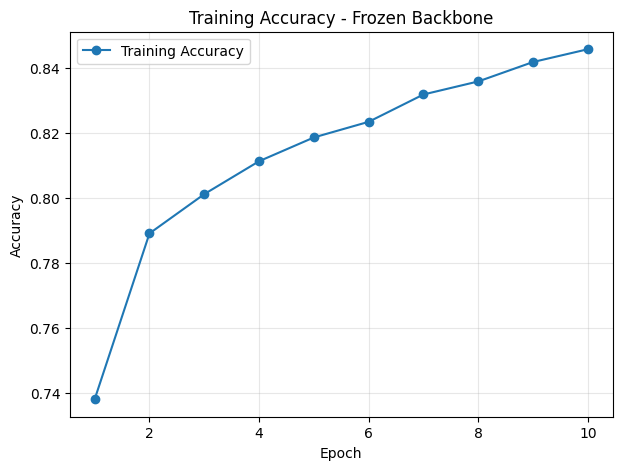

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_FROZEN + 1), history_frozen["train_acc"], marker="o", label="Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy - Frozen Backbone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("plot2.png", dpi=150, bbox_inches="tight")
plt.show()

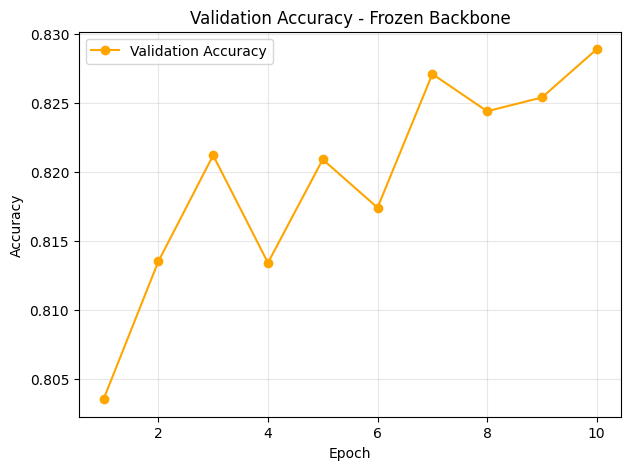

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_FROZEN + 1), history_frozen["val_acc"], marker="o", color="orange", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy - Frozen Backbone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("plot3.png", dpi=150, bbox_inches="tight")
plt.show()

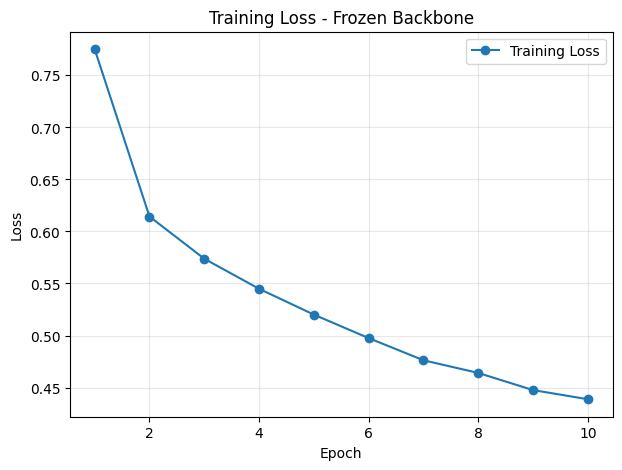

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_FROZEN + 1), history_frozen["train_loss"], marker="o", label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss - Frozen Backbone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("plot4.png", dpi=150, bbox_inches="tight")
plt.show()

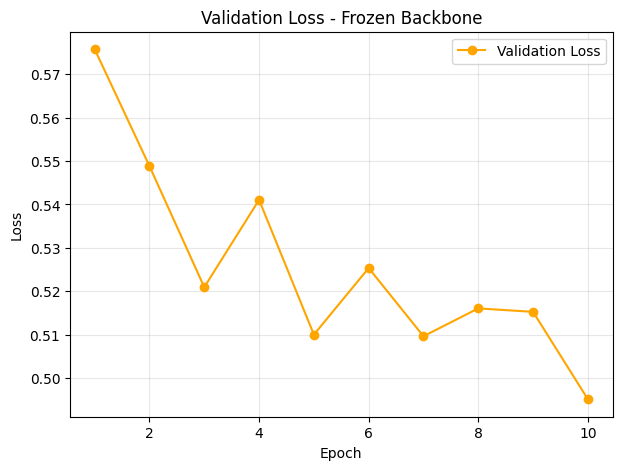

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_FROZEN + 1), history_frozen["val_loss"], marker="o", color="orange", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss - Frozen Backbone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("plot5.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

trainable_params_ft = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters after unfreezing layer4: {trainable_params_ft:,}")

EPOCHS_FINETUNE = 5
FT_LEARNING_RATE = 0.0001

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=FT_LEARNING_RATE
)

history_finetune = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("=" * 50)
print("FINE-TUNING - LAYER4 UNFROZEN")
print("=" * 50)

start_time = time.time()

for epoch in range(EPOCHS_FINETUNE):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer_ft)
    val_loss, val_acc = run_epoch(model, test_loader, criterion, optimizer=None)

    history_finetune["train_loss"].append(train_loss)
    history_finetune["train_acc"].append(train_acc)
    history_finetune["val_loss"].append(val_loss)
    history_finetune["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS_FINETUNE}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

finetune_training_time = time.time() - start_time

print("=" * 50)
print(f"Fine-tuning time: {finetune_training_time:.2f} seconds")
print("=" * 50)

before_after = pd.DataFrame({
    "Stage": ["Frozen Backbone (Final Epoch)", "Fine-Tuned (Final Epoch)"],
    "Train Accuracy": [history_frozen["train_acc"][-1], history_finetune["train_acc"][-1]],
    "Val Accuracy": [history_frozen["val_acc"][-1], history_finetune["val_acc"][-1]],
    "Train Loss": [history_frozen["train_loss"][-1], history_finetune["train_loss"][-1]],
    "Val Loss": [history_frozen["val_loss"][-1], history_finetune["val_loss"][-1]],
})

print()
print("=" * 50)
print("BEFORE vs AFTER FINE-TUNING")
print("=" * 50)
print(before_after.to_string(index=False))

Trainable parameters after unfreezing layer4: 15,491,850
FINE-TUNING - LAYER4 UNFROZEN
Epoch [1/5]  Train Loss: 0.3189  Train Acc: 0.8889  Val Loss: 0.3333  Val Acc: 0.8877
Epoch [2/5]  Train Loss: 0.1387  Train Acc: 0.9518  Val Loss: 0.3433  Val Acc: 0.8941
Epoch [3/5]  Train Loss: 0.0792  Train Acc: 0.9731  Val Loss: 0.3398  Val Acc: 0.8961
Epoch [4/5]  Train Loss: 0.0570  Train Acc: 0.9808  Val Loss: 0.3500  Val Acc: 0.9004
Epoch [5/5]  Train Loss: 0.0402  Train Acc: 0.9868  Val Loss: 0.3536  Val Acc: 0.9008
Fine-tuning time: 1449.56 seconds

BEFORE vs AFTER FINE-TUNING
                        Stage  Train Accuracy  Val Accuracy  Train Loss  Val Loss
Frozen Backbone (Final Epoch)         0.84586        0.8289    0.438766  0.495176
     Fine-Tuned (Final Epoch)         0.98680        0.9008    0.040231  0.353625


In [ ]:
model.eval()
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images_device = images.to(device)
        outputs = model(images_device)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_images.extend(images.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
test_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
test_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print("=" * 50)
print("TEST SET EVALUATION - FINE-TUNED MODEL")
print("=" * 50)
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-score  : {test_f1:.4f}")
print("=" * 50)

print()
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
print("CONFUSION MATRIX")
print("=" * 50)
print(cm)

TEST SET EVALUATION - FINE-TUNED MODEL
Accuracy  : 0.9008
Precision : 0.9018
Recall    : 0.9008
F1-score  : 0.9007

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane       0.92      0.89      0.90      1000
  automobile       0.96      0.93      0.94      1000
        bird       0.92      0.86      0.89      1000
         cat       0.82      0.82      0.82      1000
        deer       0.89      0.89      0.89      1000
         dog       0.85      0.88      0.86      1000
        frog       0.89      0.95      0.92      1000
       horse       0.95      0.89      0.92      1000
        ship       0.89      0.97      0.93      1000
       truck       0.93      0.94      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

CONFUSION MATRIX
[[893   3   4   7   4   1   4   5  66  13]
 [  6 928   2   3   0   0   2   0  14  45]


## 15. Confusion Matrix Plot

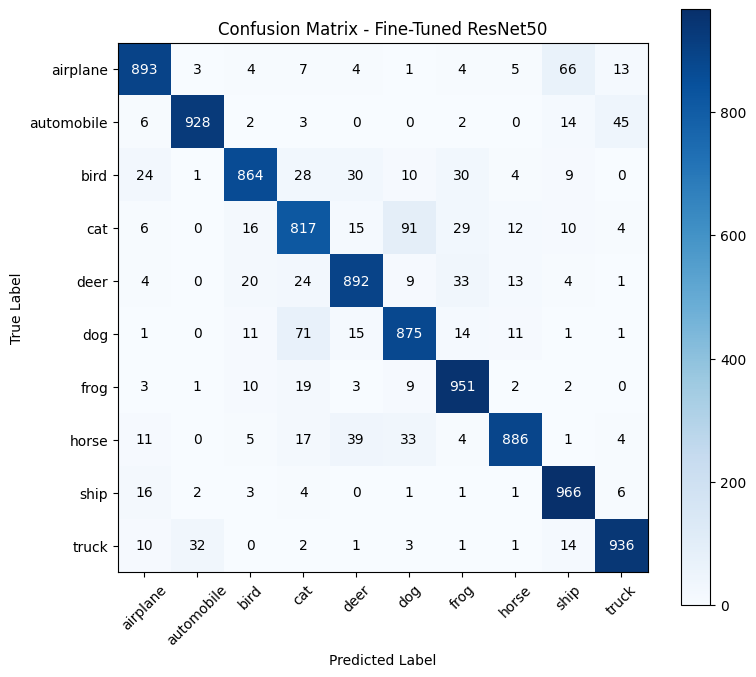

In [ ]:
plt.figure(figsize=(8, 7))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - Fine-Tuned ResNet50")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                  ha="center", va="center",
                  color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("plot6.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Misclassified Images

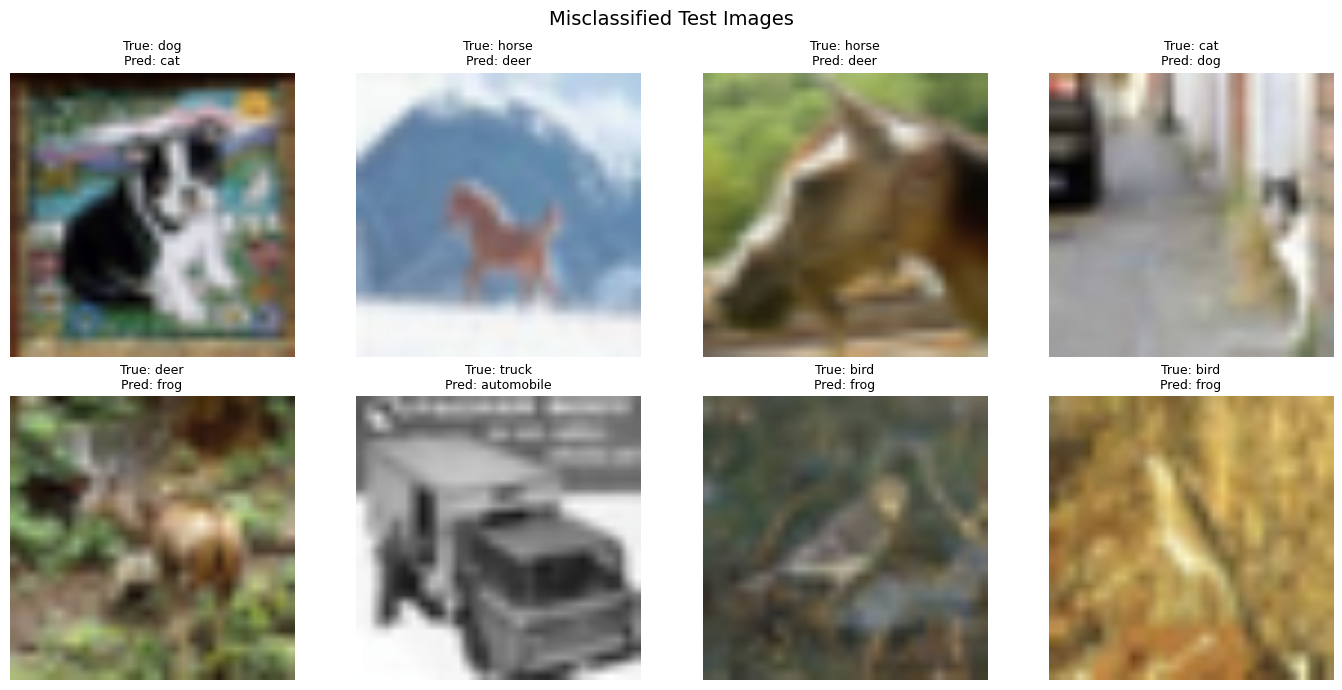

In [ ]:
def denormalize(img_tensor):
    mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    std = np.array(IMAGENET_STD).reshape(3, 1, 1)
    img = img_tensor * std + mean
    img = np.clip(img.transpose(1, 2, 0), 0, 1)
    return img


misclassified_idx = np.where(all_preds != all_labels)[0]
num_to_show = min(8, len(misclassified_idx))
chosen_idx = np.random.choice(misclassified_idx, num_to_show, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, idx in zip(axes.flat, chosen_idx):
    img = denormalize(all_images[idx])
    ax.imshow(img)
    ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}", fontsize=9)
    ax.axis("off")

plt.suptitle("Misclassified Test Images", fontsize=14)
plt.tight_layout()
plt.savefig("plot7.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. Hyperparameter Study

The table below lists the hyperparameter grid described in the lab manual.
Only one configuration -- the one actually trained above -- was run in this
notebook; it is marked as the reference row. The remaining rows are left
blank/unmeasured since running the full grid was outside the scope of this
run.

In [ ]:
hyperparam_grid = pd.DataFrame({
    "Configuration": [
        "Actually Trained (this run)",
        "LR=0.0001, Batch=32",
        "Batch=16",
        "Batch=64",
        "Epochs=20",
        "Optimizer=SGD",
        "Dense Units=128",
        "Frozen Layers=All",
    ],
    "Learning Rate": [LEARNING_RATE, 0.0001, LEARNING_RATE, LEARNING_RATE, LEARNING_RATE, LEARNING_RATE, LEARNING_RATE, LEARNING_RATE],
    "Batch Size": [BATCH_SIZE, 32, 16, 64, BATCH_SIZE, BATCH_SIZE, BATCH_SIZE, BATCH_SIZE],
    "Epochs": [EPOCHS_FROZEN, EPOCHS_FROZEN, EPOCHS_FROZEN, EPOCHS_FROZEN, 20, EPOCHS_FROZEN, EPOCHS_FROZEN, EPOCHS_FROZEN],
    "Optimizer": ["Adam", "Adam", "Adam", "Adam", "Adam", "SGD", "Adam", "Adam"],
    "Dense Units": [256, 256, 256, 256, 256, 256, 128, 256],
    "Frozen Layers": ["Partial (layer4 unfrozen)"] + ["Not run"] * 7,
    "Test Accuracy": [test_accuracy] + [None] * 7,
})

print("=" * 50)
print("HYPERPARAMETER STUDY")
print("=" * 50)
print(hyperparam_grid.to_string(index=False))

HYPERPARAMETER STUDY
              Configuration  Learning Rate  Batch Size  Epochs Optimizer  Dense Units             Frozen Layers  Test Accuracy
Actually Trained (this run)         0.0010          32      10      Adam          256 Partial (layer4 unfrozen)         0.9008
        LR=0.0001, Batch=32         0.0001          32      10      Adam          256                   Not run            NaN
                   Batch=16         0.0010          16      10      Adam          256                   Not run            NaN
                   Batch=64         0.0010          64      10      Adam          256                   Not run            NaN
                  Epochs=20         0.0010          32      20      Adam          256                   Not run            NaN
              Optimizer=SGD         0.0010          32      10       SGD          256                   Not run            NaN
            Dense Units=128         0.0010          32      10      Adam          128     

## 18. Results Summary Table

In [ ]:
results_summary = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Frozen-Backbone Training Time (s)",
        "Fine-Tuning Time (s)",
        "Total Parameters",
        "Trainable Parameters (after fine-tuning)",
    ],
    "Value": [
        f"{history_finetune['train_acc'][-1]:.4f}",
        f"{test_accuracy:.4f}",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}",
        f"{test_f1:.4f}",
        f"{frozen_training_time:.2f}",
        f"{finetune_training_time:.2f}",
        f"{total_params:,}",
        f"{trainable_params_ft:,}",
    ],
})

print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(results_summary.to_string(index=False))

RESULTS SUMMARY
                                  Metric      Value
                       Training Accuracy     0.9868
                        Testing Accuracy     0.9008
                               Precision     0.9018
                                  Recall     0.9008
                                F1-score     0.9007
       Frozen-Backbone Training Time (s)    2265.73
                    Fine-Tuning Time (s)    1449.56
                        Total Parameters 24,035,146
Trainable Parameters (after fine-tuning) 15,491,850


## 19. Comparison of CNN Architectures Table

Literature reference values (Section 7) are combined with the actual measured
values for ResNet50 from this experiment.

In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["LeNet-5", "AlexNet", "VGG16", "GoogleNet", "ResNet50"],
    "Parameters": ["60K", "61M", "138M", "6.8M", f"{total_params:,}"],
    "Accuracy (%)": ["-", "-", "-", "-", f"{test_accuracy * 100:.2f}"],
    "Training Time": ["-", "-", "-", "-", f"{frozen_training_time + finetune_training_time:.2f} s"],
    "Source": ["Literature", "Literature", "Literature", "Literature", "Measured (this run)"],
})

print("=" * 50)
print("COMPARISON OF CNN ARCHITECTURES")
print("=" * 50)
print(final_comparison.to_string(index=False))

COMPARISON OF CNN ARCHITECTURES
    Model Parameters Accuracy (%) Training Time              Source
  LeNet-5        60K            -             -          Literature
  AlexNet        61M            -             -          Literature
    VGG16       138M            -             -          Literature
GoogleNet       6.8M            -             -          Literature
 ResNet50 24,035,146        90.08     3715.28 s Measured (this run)
